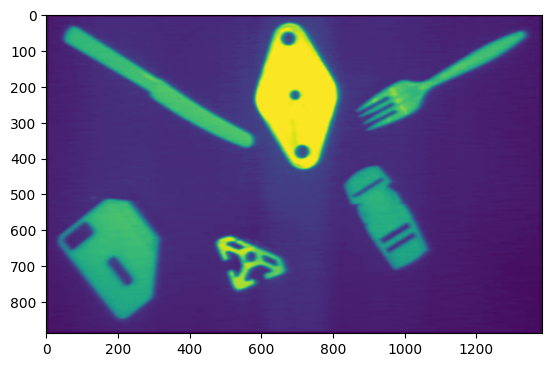

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image
img = cv2.imread("/content/drive/MyDrive/lab/dataset/SimpleThresholding1.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(img)

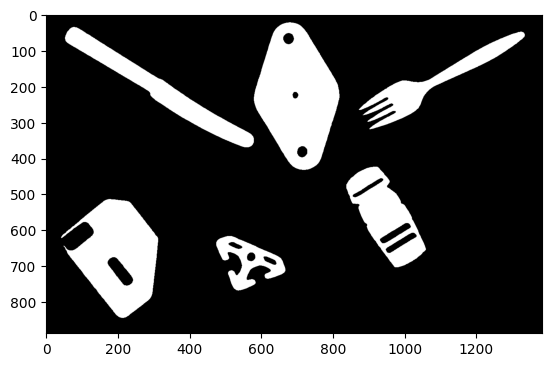

In [27]:
blur = cv2.GaussianBlur(img, (9,9), 1)
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY+cv2.THRESH_OTSU)
plt.imshow(thresh, cmap="gray")

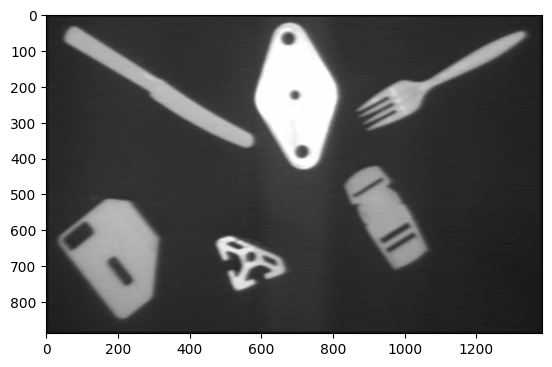

In [16]:
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Convert grayscale to BGR for visualization
output = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
plt.imshow(output)

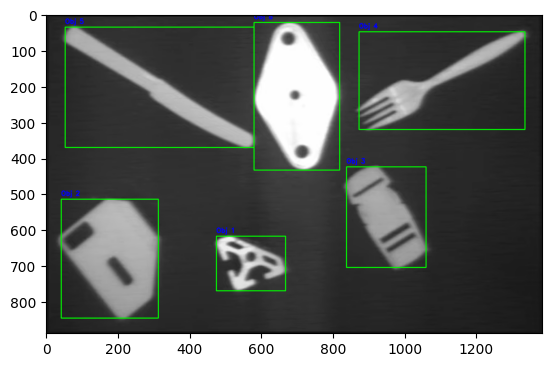

In [28]:
for i, cnt in enumerate(contours):
    # Get bounding box
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(output, (x,y), (x+w, y+h), (0,255,0), 2)
    cv2.putText(output, f"Obj {i+1}", (x, y-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

# Save or show result
plt.imshow( output)
#cv2.imwrite("recognized_objects.png", output)

Detected 721 keypoints, descriptor shape = (721, 128)


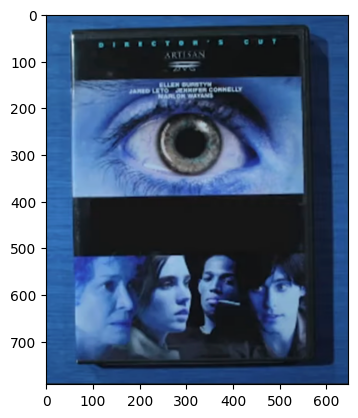

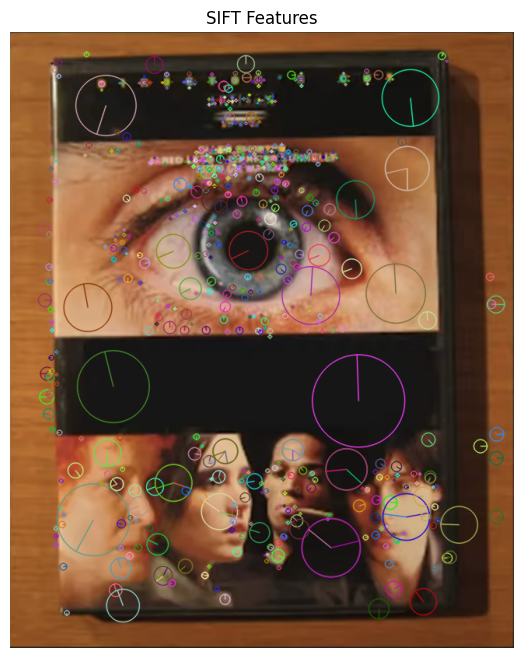

In [34]:
# Load image
img_1 = cv2.imread("/content/drive/MyDrive/lab/dataset/Img1.png")
plt.imshow(img_1)
gray = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)

# Create SIFT detector
sift = cv2.SIFT_create()

# Detect keypoints & compute descriptors
kps, desc = sift.detectAndCompute(img_1, None)

print(f"Detected {len(kps)} keypoints, descriptor shape = {desc.shape}")

# Draw keypoints (location, scale, orientation)
vis = cv2.drawKeypoints(
    img_1, kps, None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS
)

# Show
plt.figure(figsize=(12,8))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
plt.title("SIFT Features")
plt.axis("off")
plt.show()

In [43]:
(h,w,_) = img_1.shape
center = (w//2,h//2)

M = cv2.getRotationMatrix2D(center, 45, 1.0)
rotated = cv2.warpAffine(img_1, M, (w,h))
kp1, des1 = sift.detectAndCompute(img_1,None)
kp2, des2 = sift.detectAndCompute(rotated,None)
# --- BFMatcher + KNN (k=2) ---
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False)
knn = bf.knnMatch(des1, des2, k=2)

Good matches after ratio test: 504


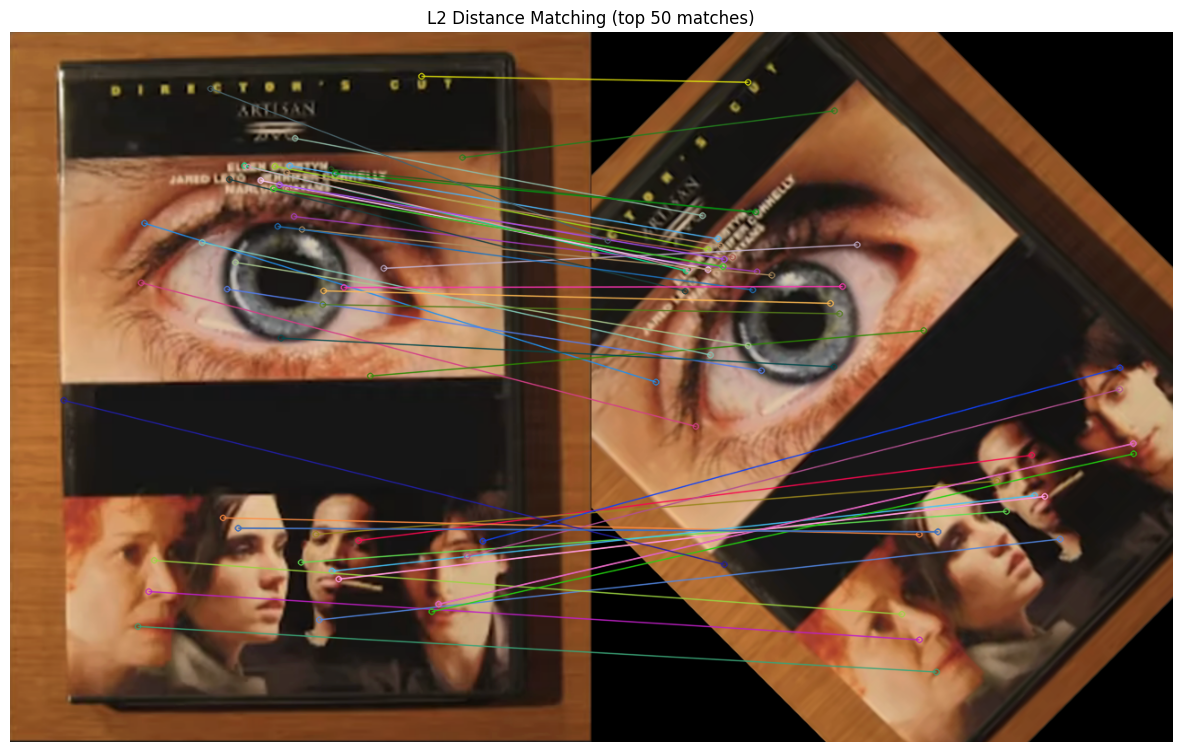

In [44]:
# Lowe’s ratio test
ratio = 0.75
matches = []
for m, n in knn:
    if m.distance < ratio * n.distance:
        matches.append(m)
print(f"Good matches after ratio test: {len(matches)}")

# sort by distance and keep best N
matches = sorted(matches, key=lambda m: m.distance)
N = 50
matches = matches[:N]

# --- Draw matches ---
match_vis = cv2.drawMatches(
    img_1, kp1, rotated, kp2, matches, None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
)

plt.figure(figsize=(15,10))
plt.imshow(cv2.cvtColor(match_vis, cv2.COLOR_BGR2RGB))
plt.title(f"L2 Distance Matching (top {N} matches)")
plt.axis("off")
plt.show()